[<< Sommaire QC](../README.md)

# Workflow : Téléchargement et gestion des datasets

Ce notebook démontre l'utilisation des scripts `scripts/datasets/` pour télécharger,
consolider et visualiser des données de marché utilisées dans les stratégies QuantConnect.

**Prérequis** : `pip install pandas yfinance matplotlib`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Répertoire de sortie par défaut pour les datasets
DATASETS_DIR = Path("../datasets")
DATASETS_DIR.mkdir(exist_ok=True)

print(f"Datasets dir: {DATASETS_DIR.resolve()}")

Datasets dir: C:\dev\CoursIA\MyIA.AI.Notebooks\QuantConnect\datasets


## 1. Téléchargement via yfinance

Utilise le script `download_yfinance.py` avec cache Parquet local.

In [2]:
# Télécharger SPY et TLT (actions/ETF)
!python ../../../scripts/datasets/download_yfinance.py --symbols SPY,TLT --start 2020-01-01 --end 2024-12-31 --output-dir {DATASETS_DIR}/yfinance

yfinance download: 2 symbols, 2020-01-01 -> 2024-12-31, interval=1d
  Cache hit: SPY_9cf211eddf14.parquet
  Written: ..\datasets\yfinance\SPY_2020-01-01_2024-12-31.csv (1257 rows)
  Cache hit: TLT_a5d4892822d6.parquet
  Written: ..\datasets\yfinance\TLT_2020-01-01_2024-12-31.csv (1257 rows)

Done: 2/2 files written to ..\datasets\yfinance


In [3]:
# Charger et afficher les données SPY
spy = pd.read_csv(DATASETS_DIR / "yfinance" / "SPY_2020-01-01_2024-12-31.csv", parse_dates=["Date"], index_col="Date")
print(f"SPY: {len(spy)} jours, {spy.index.min().date()} -> {spy.index.max().date()}")
spy.head()

SPY: 1257 jours, 2020-01-02 -> 2024-12-30


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,296.888153,296.906448,294.749706,295.672721,59151200
2020-01-03,294.640106,295.764174,293.442942,293.497772,77709700
2020-01-06,295.764099,295.846344,292.766587,292.885394,55653900
2020-01-07,294.932465,295.672695,294.484651,295.197466,40496400
2020-01-08,296.504364,297.719796,294.877681,295.124415,68296000


### Exercice 1 : Calculer les returns et statistiques de base

Chargez les donnees SPY et calculez les **returns journaliers**, la **moyenne**, l'**ecart-type** et le **Sharpe Ratio** annuelise.

**Indices** :
- `# Indice` : `returns = df['Close'].pct_change()`
- `# Indice` : Sharpe annualise = `mean(returns) / std(returns) * sqrt(252)`
- `# Etape 1` : Charger le CSV et calculer les returns
- `# Etape 2` : Calculer mean et std des returns
- `# Etape 3` : Calculer le Sharpe Ratio annualise

In [ ]:
# Exercice 1 : Returns et Sharpe Ratio de SPY
# TODO etudiant : Calculer returns journaliers et Sharpe Ratio annualise
# Etape 1 : returns = spy['Close'].pct_change()
# Etape 2 : mean_ret = returns.mean(), std_ret = returns.std()
# Etape 3 : sharpe = mean_ret / std_ret * np.sqrt(252)
sharpe_spy = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : Returns et Sharpe Ratio de SPY")

Exercice a completer


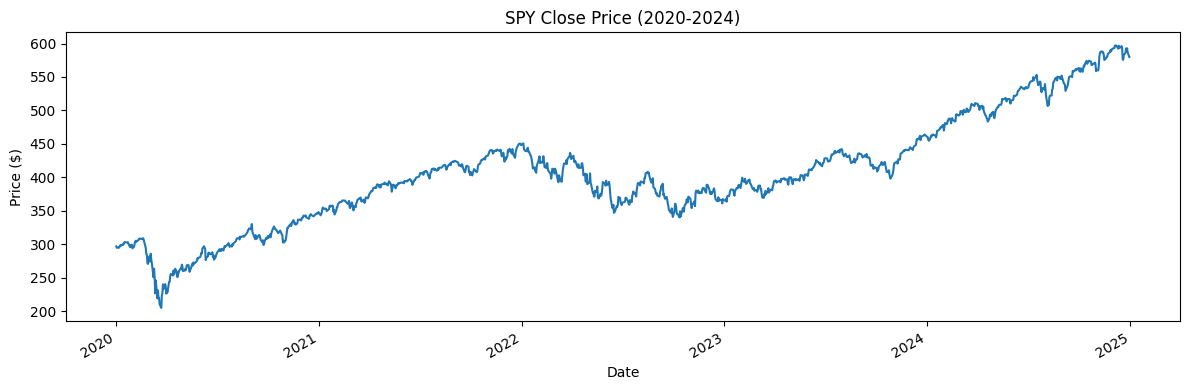

In [4]:
# Visualiser SPY Close
fig, ax = plt.subplots(figsize=(12, 4))
spy["Close"].plot(ax=ax, title="SPY Close Price (2020-2024)")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 2. Données crypto (archive consolidée)

Utilise `manage_crypto_archive.py` qui combine yfinance et CoinGecko.

In [5]:
# Construire l'archive BTC
!python ../../../scripts/datasets/manage_crypto_archive.py --symbol BTC --start 2019-01-01 --end 2024-12-31 --output-dir {DATASETS_DIR}/crypto_archive

Building crypto archive: BTC [2019-01-01 -> 2024-12-31]
  Downloaded via yfinance: 2191 rows
  Written: ..\datasets\crypto_archive\BTC_USDT_archive.csv (2191 rows, 2019-01-01 -> 2024-12-30)


In [6]:
# Charger l'archive BTC
btc = pd.read_csv(DATASETS_DIR / "crypto_archive" / "BTC_USDT_archive.csv", parse_dates=["date"])
print(f"BTC: {len(btc)} jours, {btc['date'].min().date()} -> {btc['date'].max().date()}")
btc.head()

BTC: 2191 jours, 2019-01-01 -> 2024-12-30


,date,open,high,low,close,volume
0,2019-01-01,3746.713379,3850.913818,3707.231201,3843.520020,4324200990
1,2019-01-02,3849.216309,3947.981201,3817.409424,3943.409424,5244856836
2,2019-01-03,3931.048584,3935.685059,3826.222900,3836.741211,4530215219
3,2019-01-04,3832.040039,3865.934570,3783.853760,3857.717529,4847965467
4,2019-01-05,3851.973877,3904.903076,3836.900146,3845.194580,5137609824


### Exercice 2 : Calculer la correlation BTC vs SPY

Calculez la **correlation rolling 30 jours** entre les returns de BTC et SPY. Une correlation elevee reduit l'interet de la diversification.

**Indices** :
- `# Indice` : Mergez les deux DataFrames sur la date, puis calculez `returns.rolling(30).corr()`
- `# Etape 1` : Calculer les returns pour SPY et BTC
- `# Etape 2` : Merger les returns sur la colonne date
- `# Etape 3` : Calculer la correlation rolling 30j

In [ ]:
# Exercice 2 : Correlation BTC vs SPY
# TODO etudiant : Calculer la correlation rolling 30 jours entre BTC et SPY
# Etape 1 : Returns SPY et BTC
# Etape 2 : Merger sur la date
# Etape 3 : Correlation rolling 30j
corr_rolling = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : Correlation BTC vs SPY")

Exercice a completer


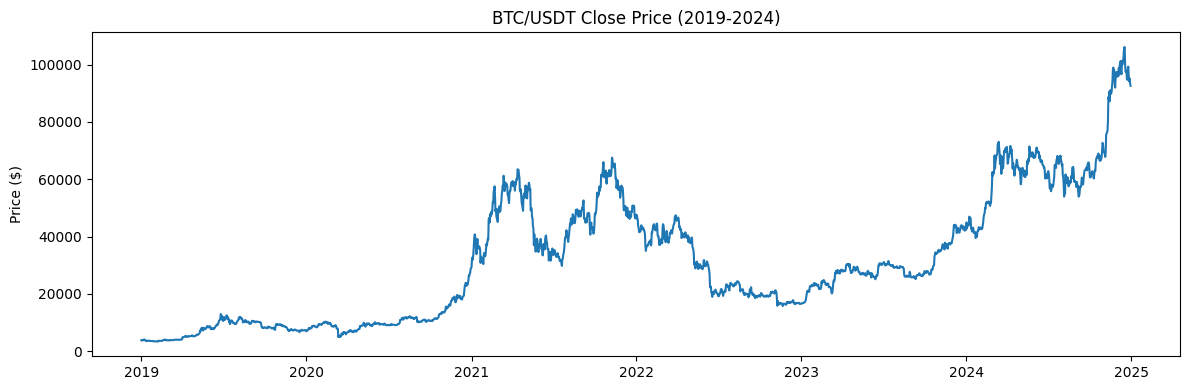

In [7]:
# Visualiser BTC Close
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(btc["date"], btc["close"])
ax.set_title("BTC/USDT Close Price (2019-2024)")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 3. Données Binance (klines haute résolution)

Pour des données intraday, utiliser `download_binance_archive.py`.

In [8]:
# Télécharger les klines journaliers BTC d'un mois
!python ../../../scripts/datasets/download_binance_archive.py --symbol BTCUSDT --start 2024-01-01 --end 2024-03-31 --interval 1d --output-dir {DATASETS_DIR}/binance

Binance archive: BTCUSDT 1d spot, 3 periods (monthly)
  2024-01: 31 rows -> BTCUSDT_1d_2024-01.csv
  2024-02: 29 rows -> BTCUSDT_1d_2024-02.csv
  2024-03: 31 rows -> BTCUSDT_1d_2024-03.csv

Done: 3 files written to ..\datasets\binance


In [9]:
# Lister et charger les fichiers Binance téléchargés
binance_files = sorted((DATASETS_DIR / "binance").glob("BTCUSDT_1d_*.csv"))
print(f"{len(binance_files)} fichiers Binance")

if binance_files:
    dfs = [pd.read_csv(f) for f in binance_files]
    btc_klines = pd.concat(dfs, ignore_index=True)
    btc_klines["date"] = pd.to_datetime(btc_klines["open_time"], unit="ms")
    print(f"Total: {len(btc_klines)} rangées")
    btc_klines.head()

3 fichiers Binance
Total: 91 rangées


## 4. Mise à jour de l'archive crypto

Pour mettre à jour une archive existante avec les données les plus récentes :

In [10]:
# Mettre à jour l'archive BTC (ajoute les nouvelles données)
!python ../../../scripts/datasets/manage_crypto_archive.py --symbol BTC --update --output-dir {DATASETS_DIR}/crypto_archive

Updating BTC archive: appending 2024-12-30 -> 2026-06-03


Traceback (most recent call last):
  File "C:\dev\CoursIA\scripts\datasets\manage_crypto_archive.py", line 207, in <module>
    main()
    ~~~~^^
  File "C:\dev\CoursIA\scripts\datasets\manage_crypto_archive.py", line 199, in main
    update_archive(args.symbol.upper(), output_dir)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\dev\CoursIA\scripts\datasets\manage_crypto_archive.py", line 157, in update_archive
    df_combined = df_combined.drop_duplicates(subset=["date"]).sort_values("date")
  File "C:\Users\jsboi\AppData\Roaming\Python\Python313\site-packages\pandas\core\frame.py", line 8358, in sort_values
    indexer = nargsort(
        k, kind=kind, ascending=ascending, na_position=na_position, key=key
    )
  File "C:\Users\jsboi\AppData\Roaming\Python\Python313\site-packages\pandas\core\sorting.py", line 442, in nargsort
    indexer = non_nan_idx[non_nans.argsort(kind=kind)]
                          ~~~~~~~~~~~~~~~~^^^^^^^^^^^
TypeError: '<' not supported between

In [11]:
# Lister toutes les archives disponibles
!python ../../../scripts/datasets/manage_crypto_archive.py --list --output-dir {DATASETS_DIR}/crypto_archive

Symbol   Start        End          Rows     Size      
--------------------------------------------------
BTC      2019-01-01 2024-12-30 2191     178 KB


### Exercice 3 : Ajouter ETH a l'archive et calculer la beta

Telechargez les donnees **ETH** et ajoutez-les a l'archive crypto. Calculez ensuite la **beta de BTC par rapport a ETH** (sensibilite du prix BTC aux mouvements d'ETH).

**Indices** :
- `# Indice` : Beta = covariance(BTC, ETH) / variance(ETH)
- `# Indice` : Utilisez `np.cov()` ou `.cov()` de pandas
- `# Etape 1` : Telecharger ETH avec le script manage_crypto_archive.py
- `# Etape 2` : Calculer les returns de BTC et ETH
- `# Etape 3` : Calculer beta = cov(BTC,ETH) / var(ETH)

In [ ]:
# Exercice 3 : Beta de BTC par rapport a ETH
# TODO etudiant : Telecharger ETH et calculer la beta BTC/ETH
# Etape 1 : Telecharger les donnees ETH
# Etape 2 : Calculer les returns BTC et ETH
# Etape 3 : Beta = cov(btc_ret, eth_ret) / var(eth_ret)
beta_btc_eth = None  # TODO etudiant : remplacer par le calcul
print("Exercice a completer : Beta de BTC par rapport a ETH")

Exercice a completer


## 5. Résumé des outils disponibles

| Script | Source | Cas d'usage |
|--------|--------|-------------|
| `download_yfinance.py` | Yahoo Finance | Actions, ETF, crypto (daily+) |
| `download_binance_archive.py` | Binance data.vision | Crypto intraday (1m-1d) |
| `download_kaggle.py` | Kaggle | Datasets académiques |
| `download_qc_data.py` | QuantConnect lean-cli | Données QC (equity, forex, futures) |
| `manage_crypto_archive.py` | yfinance + CoinGecko | Archive crypto consolidée |

Documentation complète : `scripts/datasets/README.md`